In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


In [24]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
Vels = ['U200']
Len = ['L100']
RPMs = ['RPM0', 'RPM3' ,'RPM6', 'RPM9', 'RPM12']

vels = h5file['Wide'][Vels[0]][Len[0]][RPMs[4]]
u = vels[:,:,:,0]
v = vels[:,:,:,1]

left  = int(u.shape[1]/2)###############Temp line
right = int(u.shape[1]-(u.shape[1]/2))###############Temp line

## Import flow field 
runRot = 6
runInj = 1
data = h5file['Wide'][Vels[0]][Len[0]]['RPM12']

uTemp = data[:, :, : ,0] #* mask #/ vel0[runInj]
vTemp = data[:, :, : ,1] #* mask #/ vel0[runInj]
h5file.close()

uTrans = np.transpose(uTemp, (0, 2, 1))

Filter Frequency = 0.2828Hz


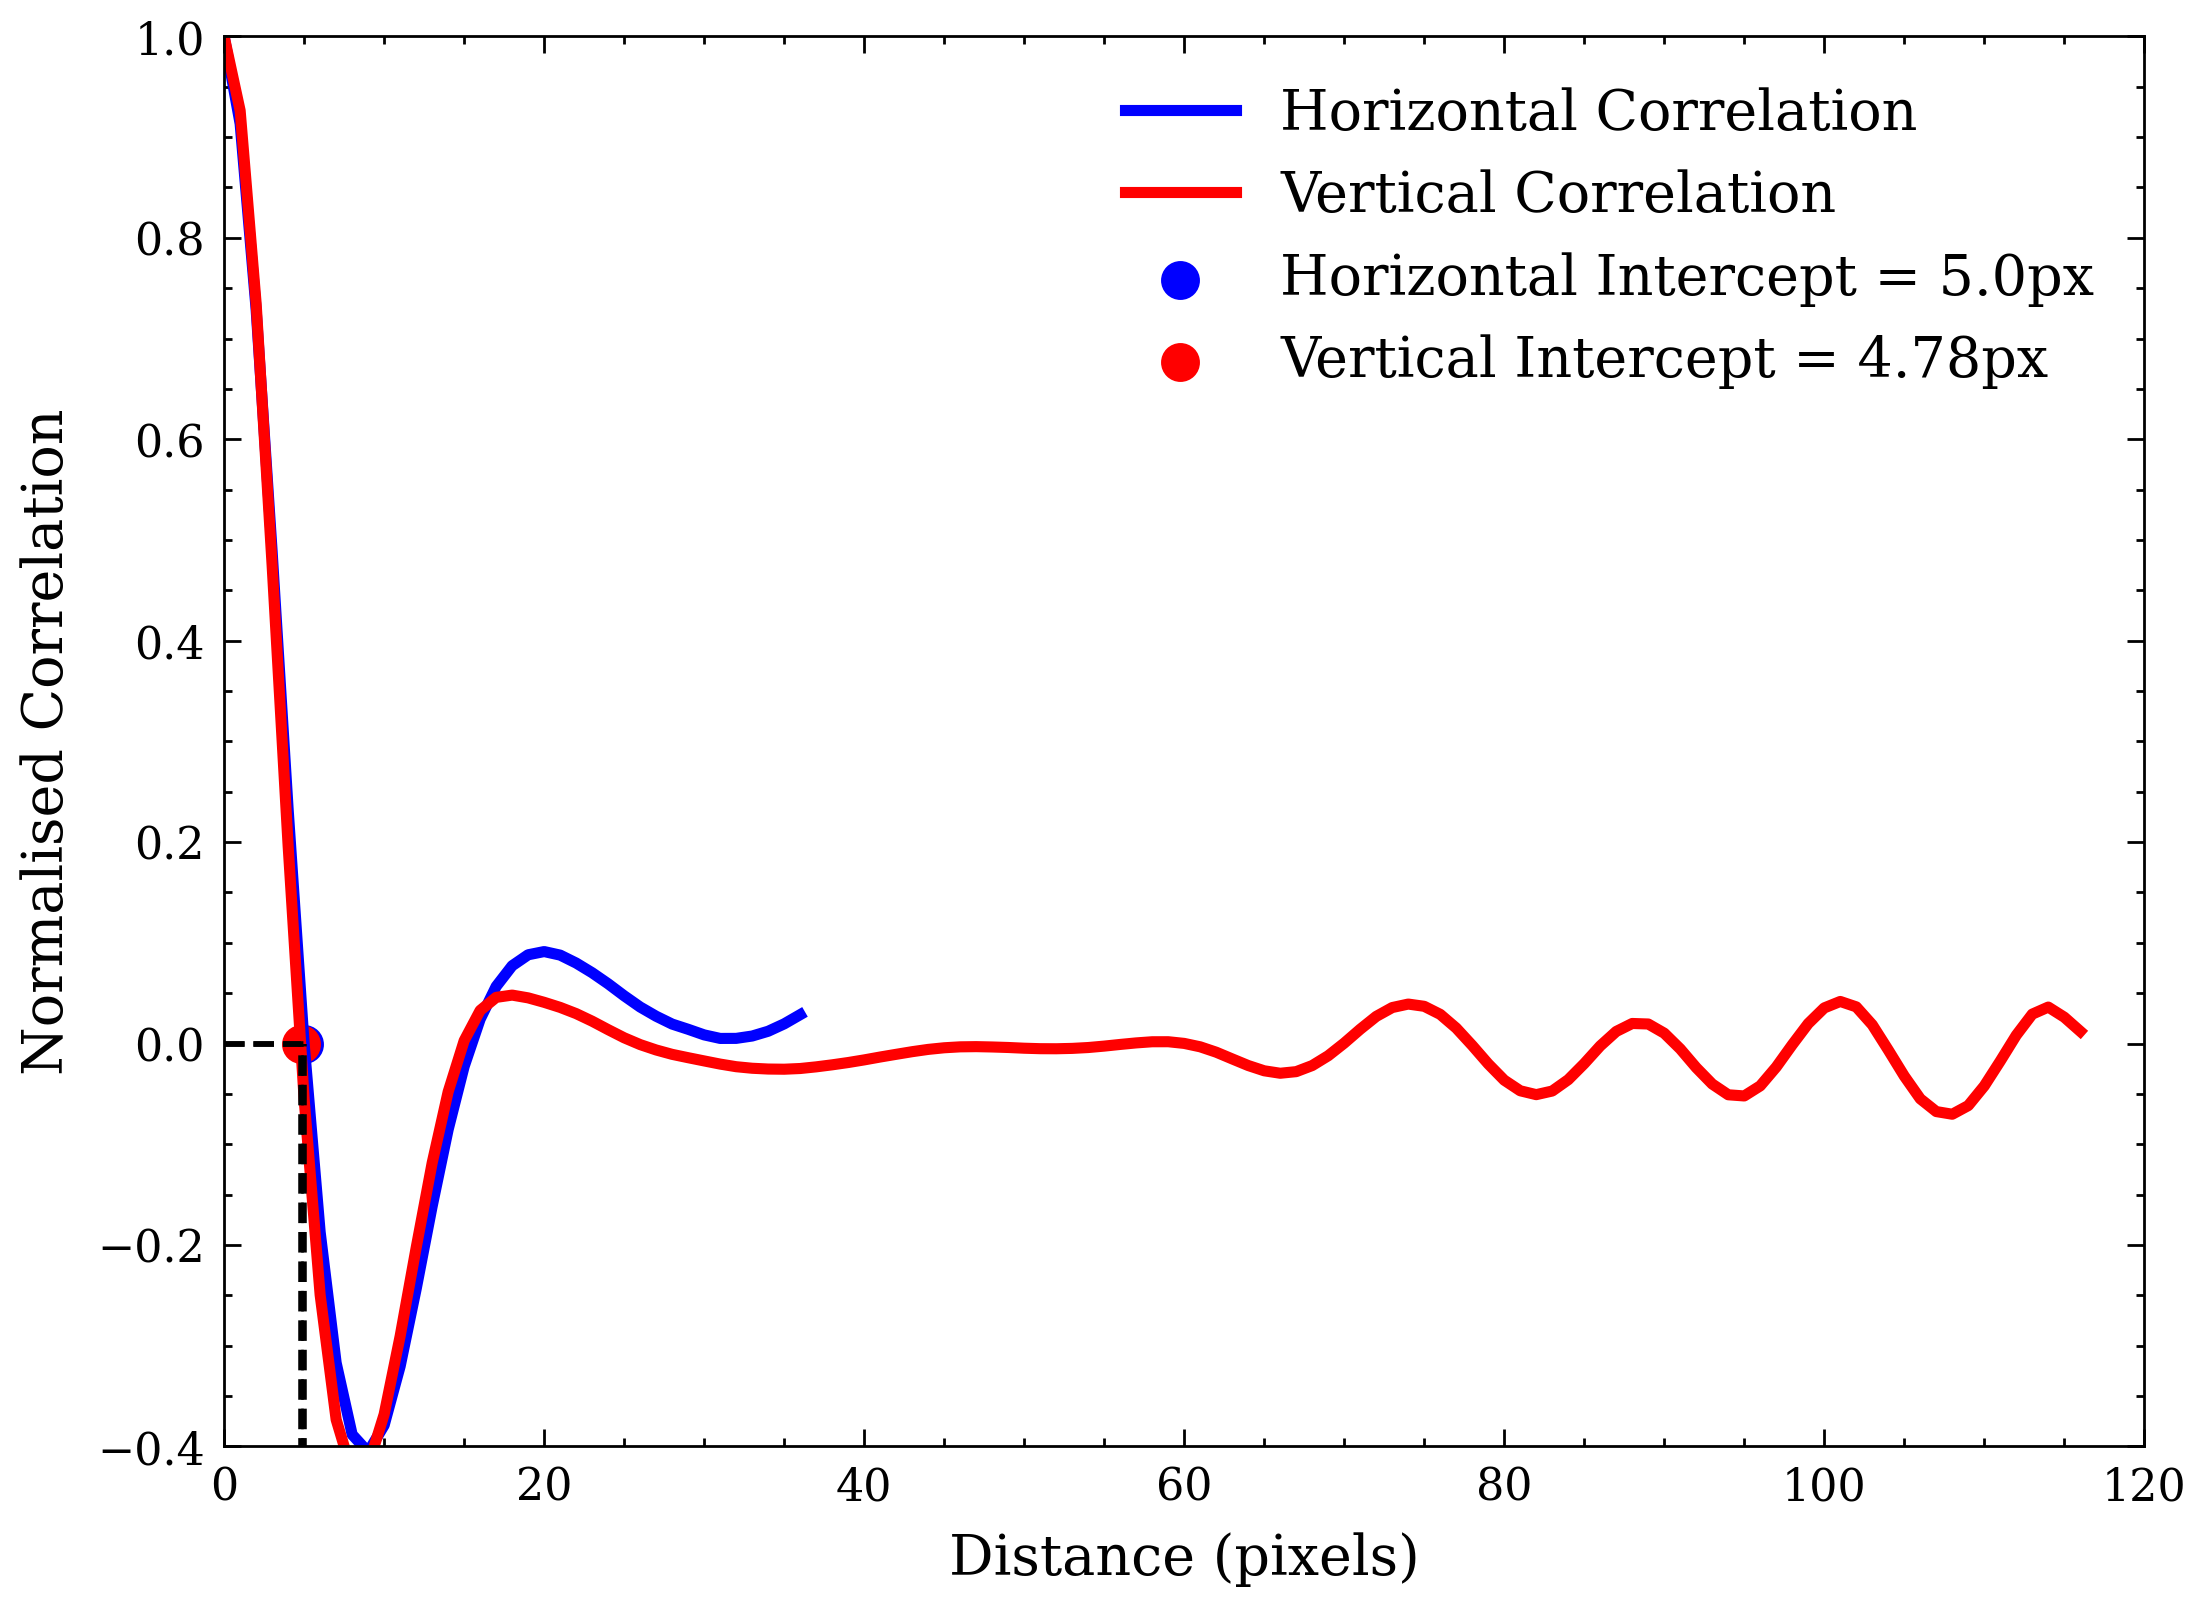

In [23]:
# distH, distV, corrH, corrV, XC, YC, angDL


IWsF = oj.IWFilter(uTrans, 45, fps=60, rpm = 12)#, phase = 1)
# distH, distV, corrH, corrV, XC, YC,angDL = oj.TwoPtCorrIWs(IWsF[:, 2:, :left])
distH, distV, corrH, corrV, XC, YC,angDR = oj.TwoPtCorrIWs(IWsF[:, 2:, right:])

XC = oj.FindFirstIntercept(corrH)
YC = oj.FindFirstIntercept(corrV)

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(corrH, label='Horizontal Correlation', color = 'blue')
ax.plot(corrV, label='Vertical Correlation', color='red')
ax.scatter(XC, 0, color='blue', label=f'Horizontal Intercept = {round(XC, 2)}px')
ax.hlines(y=0, xmin=0, xmax=XC, linewidth=1, color='k', linestyles='dashed')
ax.vlines(x=XC, ymin=-0.5, ymax=0, linewidth=1, color='k', linestyles='dashed')
ax.scatter(YC, 0, color='red', label=f'Vertical Intercept = {round(YC, 2)}px')
ax.hlines(y=0, xmin=0, xmax=YC, linewidth=1, color='k', linestyles='dashed')
ax.vlines(x=YC, ymin=-0.5, ymax=0, linewidth=1, color='k', linestyles='dashed')
ax.set_xlim(0, 120)
ax.set_ylim(-0.4, 1)

ax.set_xlabel('Distance (pixels)')
ax.set_ylabel('Normalised Correlation')
plt.legend()